In [1]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

import sys

sys.path.append("../")

In [2]:
import numpy as np

seq_length = 128
dim = 2
noise = 0.05


def sample_circle(n, max_n=seq_length, dim=2, noise=0.05):
    points = np.full((max_n, dim), -1, dtype=np.float32)
    sample_points = np.random.randn(n, dim)
    sample_points /= np.linalg.norm(sample_points, axis=1, keepdims=True)
    r = np.random.uniform(0.5, 1, size=dim)
    sample_points *= r  # Scale by random radius
    if noise > 0:
        noise_points = np.random.normal(0, 1, sample_points.shape) * noise * np.min(r)
        sample_points += noise_points
    points[:n, :] = sample_points
    return points


def sample_square(n, max_n=seq_length, dim=2, noise=0.05):
    points = np.full((max_n, dim), -1, dtype=np.float32)
    sample_points = np.random.uniform(-1, 1, (n, dim))
    sample_points /= np.linalg.norm(sample_points, axis=1, keepdims=True, ord=np.inf)
    r = np.random.uniform(0.5, 1, size=dim)
    sample_points *= r  # Scale by random radius
    if noise > 0:
        noise_points = np.random.normal(0, 1, sample_points.shape) * noise * np.min(r)
        sample_points += noise_points
    points[:n, :] = sample_points
    return points


dataset_size = 20000
X_sphere = np.zeros((dataset_size, seq_length, dim), dtype=np.float32)
X_square = np.zeros((dataset_size, seq_length, dim), dtype=np.float32)

for iter in range(dataset_size):
    n = np.random.randint(seq_length // 2, seq_length + 1)
    X_sphere[iter, :, :] = sample_circle(n, seq_length, dim, noise=noise)
    X_square[iter, :, :] = sample_square(n, seq_length, dim, noise=noise)

X = np.concatenate([X_sphere, X_square], axis=0)
y = np.concatenate(
    [
        np.zeros((dataset_size, 1), dtype=np.float32),
        np.ones((dataset_size, 1), dtype=np.float32),
    ],
    axis=0,
)

np.random.seed(42)
shuffle_indices = np.random.permutation(X.shape[0])
X = X[shuffle_indices]
y = y[shuffle_indices]

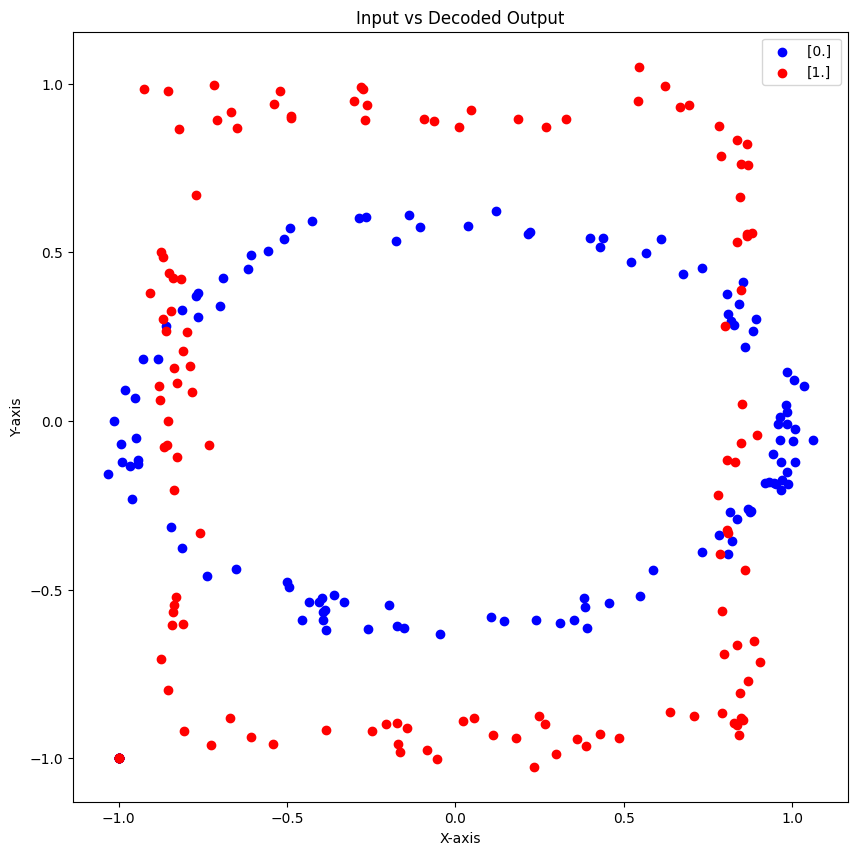

In [3]:
sample = X_square[2:3]
event = 3
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(X[event, :, 0], X[event, :, 1], label=f"{y[event]} ", color="blue")
ax.scatter(X[event + 2, :, 0], X[event + 2, :, 1], label=f"{y[event+2]}", color="red")
ax.set_title("Input vs Decoded Output")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.legend()
plt.show()

In [4]:
from src.model.components import (
    MultiHeadAttentionStack,
    MultiHeadAttentionBlock,
    SelfAttentionStack,
    SelfAttentionBlock,
    PoolingAttentionBlock,
    GenerateMask,
    MLP,
)

feature_dim = 8
num_heads = 4
dropout_rate = 0


input = keras.layers.Input(shape=(seq_length, dim), name="input")
mask = GenerateMask(name="mask")(input)
input_embedding = MLP(
    num_layers=4,
    output_dim=feature_dim,
    activation="relu",
    name="input_embedding",
    dropout_rate=dropout_rate,
)(input)

self_attention = SelfAttentionStack(
    num_heads=num_heads,
    key_dim=feature_dim,
    stack_size=3,
    name="self_attention",
    dropout_rate=dropout_rate,
    pre_ln=True,
)(input_embedding, mask=mask)
pooling = PoolingAttentionBlock(
    num_seeds=1,
    key_dim=feature_dim,
    name="pooling_attention",
    dropout_rate=dropout_rate,
)(self_attention, mask=mask)
latent_space = keras.layers.Flatten(name="latent_space")(pooling)
output = MLP(
    num_layers=2,
    output_dim=1,
    activation="sigmoid",
    name="output",
    dropout_rate=dropout_rate,
)(latent_space)

model = keras.Model(
    inputs=input,
    outputs=output,
    name="ClassificationModel",
)
model.compile(
    optimizer=keras.optimizers.Lion(learning_rate=1e-4),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'pooling_attention' (of type PoolingAttentionBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
model.summary()

Model: "ClassificationModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 128, 2)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_embedding     │ (None, 128, 8)    │         91 │ input[0][0]       │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask (GenerateMask) │ (None, 128, 1)    │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 128, 8)    │        936 │ input_embedding[… │
│ (SelfAttentionStac… │                   │            │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling_attention   │ (None, 1, 8)      │        616 │ self_attention[0… │
│ (PoolingAttentionB… │                   │            │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_space        │ (None, 8)         │          0 │ pooling_attentio… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (MLP)        │ (None, 1)         │         21 │ latent_space[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,664 (6.50 KB)

 Trainable params: 1,664 (6.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    ],
    shuffle=True,
    class_weight={label: 1 / np.mean(y_train == label) for label in np.unique(y_train)},
)

Epoch 1/20


/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'self_attention_block' (of type SelfAttentionBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'self_attention_block_1' (of type SelfAttentionBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'self_attention_block_2' (of type SelfAttentionBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore d

50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 437ms/step - binary_accuracy: 0.5322 - loss: 1.3739 - val_binary_accuracy: 0.5606 - val_loss: 0.6713 - learning_rate: 1.0000e-04
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 477ms/step - binary_accuracy: 0.6827 - loss: 1.3021 - val_binary_accuracy: 0.7886 - val_loss: 0.6333 - learning_rate: 1.0000e-04
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 513ms/step - binary_accuracy: 0.7748 - loss: 1.1540 - val_binary_accuracy: 0.7600 - val_loss: 0.5372 - learning_rate: 1.0000e-04
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 526ms/step - binary_accuracy: 0.7960 - loss: 1.0077 - val_binary_accuracy: 0.7811 - val_loss: 0.4965 - learning_rate: 1.0000e-04
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 540ms/step - binary_accuracy: 0.8236 - loss: 0.9111 - val_binary_accuracy: 0.8159 - val_loss: 0.4487 - learning_rate: 1.0000e-04
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 541ms/step - binary_accuracy: 0.8443 - loss: 0.8283 - val_binary_accuracy: 0.8500 - val_loss: 0.3942 - learning_ra

In [8]:
test_predictions = model.predict(X_test, batch_size=512)

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 524ms/step


In [9]:
reco_fail_index = np.where((test_predictions >= 0.5) != y_test)[0]
reco_success_index = np.where((test_predictions >= 0.5) == y_test)[0]

In [10]:
np.mean((test_predictions >= 0.5) != y_test)

np.float64(0.054875)

In [11]:
np.mean(y_test[reco_fail_index] == 0), np.mean(y_test[reco_fail_index] == 1)

(np.float64(0.2642369020501139), np.float64(0.7357630979498861))

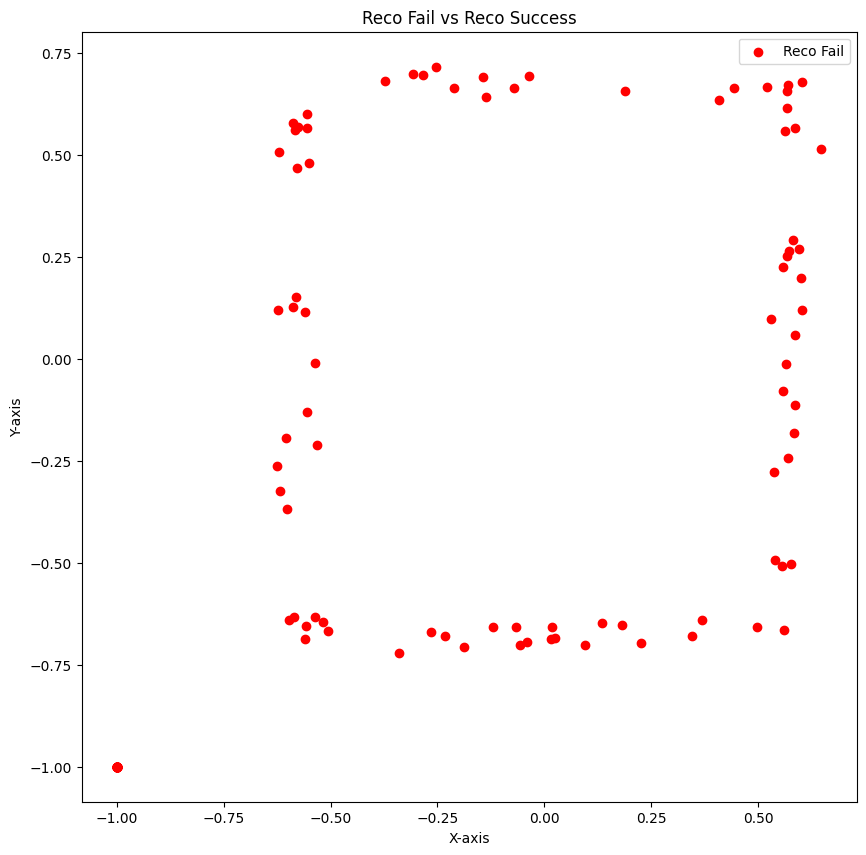

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))
i = 1
ax.scatter(
    X_test[reco_fail_index[i], :, 0],
    X_test[reco_fail_index[i], :, 1],
    label="Reco Fail",
    color="red",
)
ax.set_title("Reco Fail vs Reco Success")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.legend()
plt.show()